In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Overview: Load data
df = pd.read_csv("data/cleaned.csv")

print(f"Shape: {df.shape}")
print("\nColumns:", df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)
display(df.head())

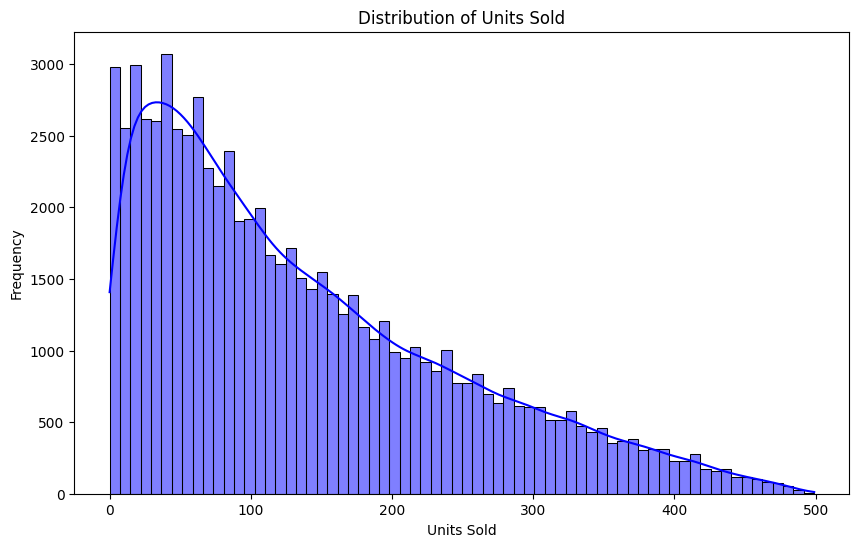

In [ ]:
# 2. Distribution of Units Sold (Target Variable)
plt.figure(figsize=(10, 6))
sns.histplot(df['Units Sold'], kde=True, color='blue')
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_2553/1319445229.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')


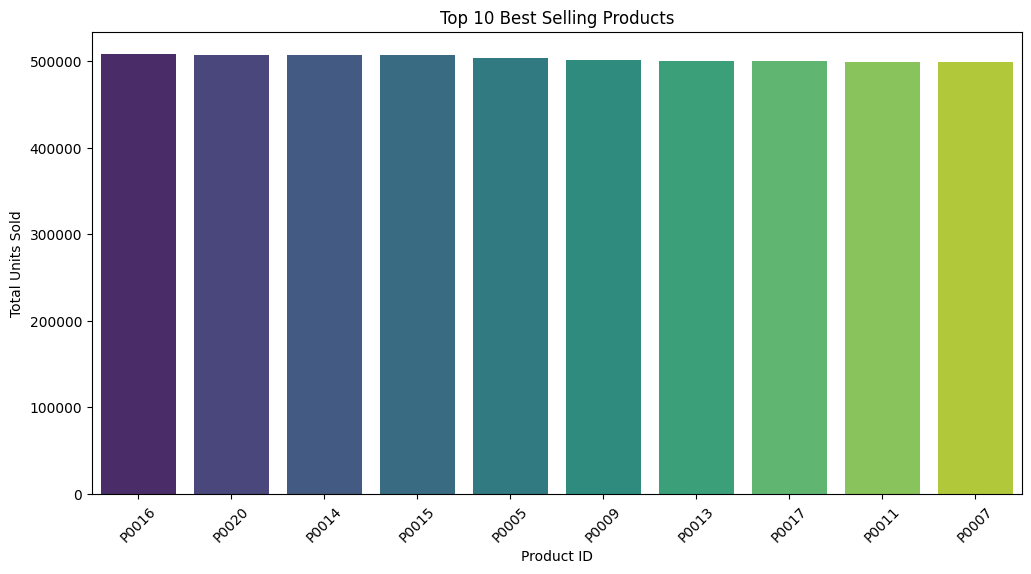

In [ ]:
# 3. Best-selling product
top_products = df.groupby('Product ID')['Units Sold'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')
plt.title('Top 10 Best Selling Products')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2553/2643528723.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette='magma')


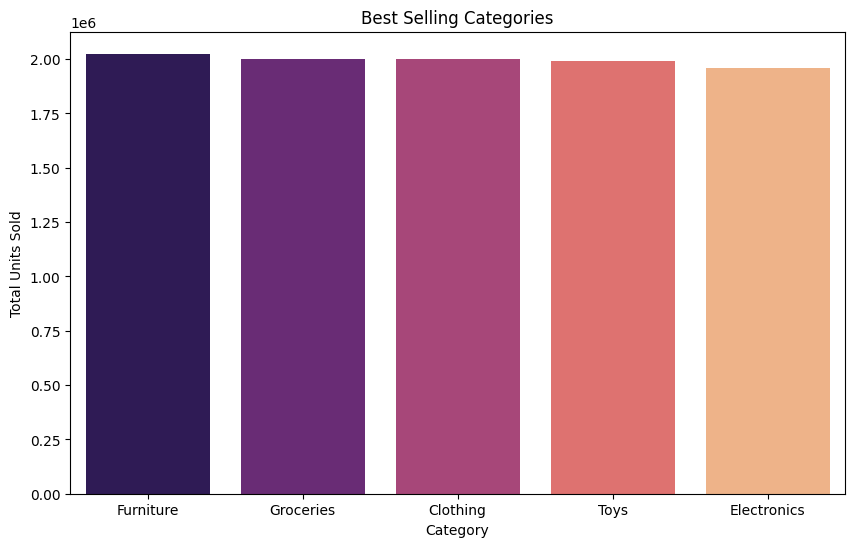

In [ ]:
# 4. Best-selling category
top_categories = df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.index, y=top_categories.values, palette='magma')
plt.title('Best Selling Categories')
plt.ylabel('Total Units Sold')
plt.show()

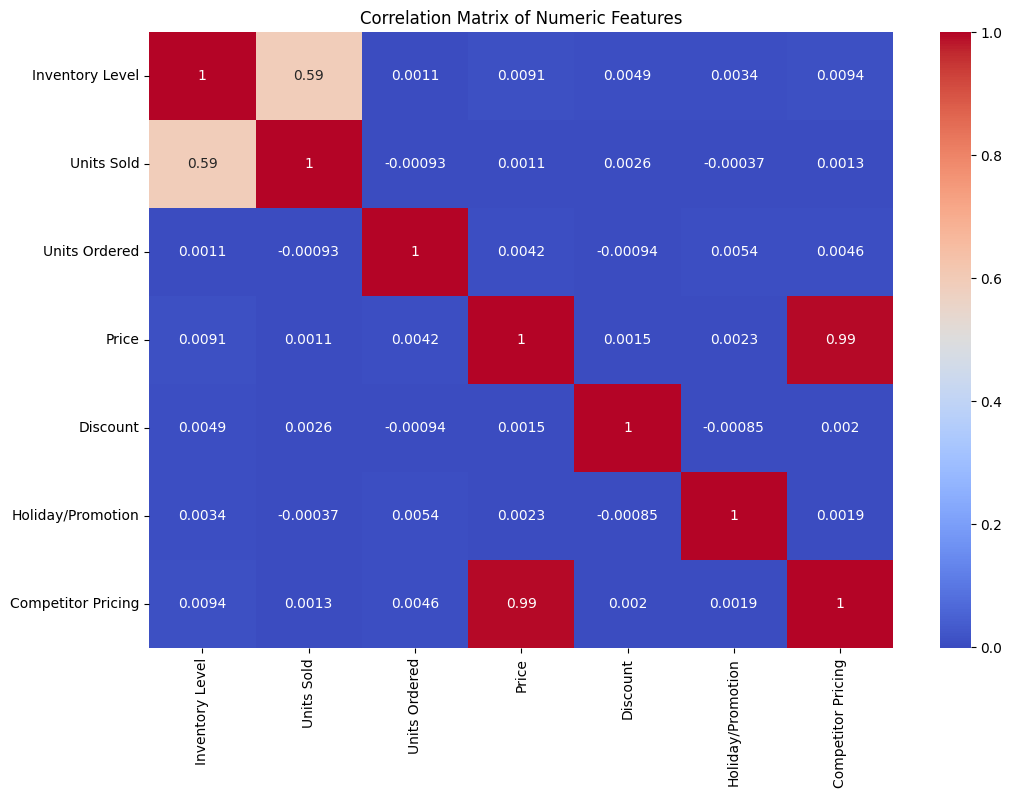

In [20]:
# 5. Correlation Matrix
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

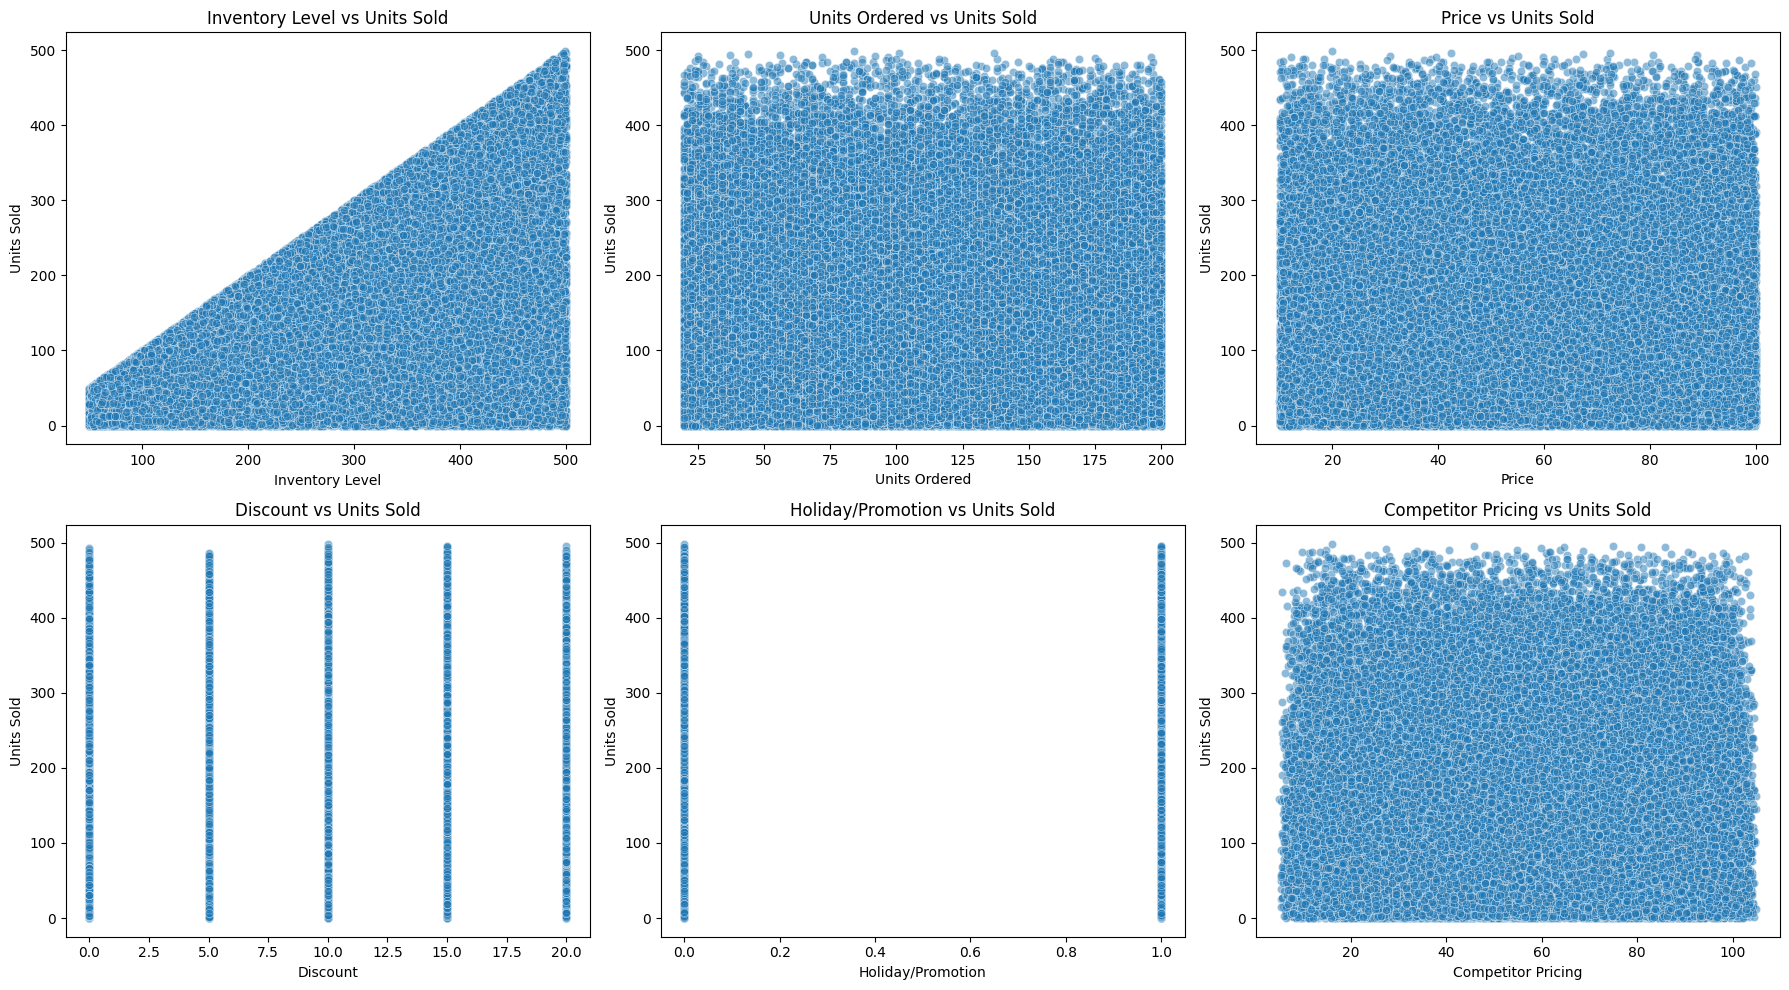

In [21]:
# 6. Features vs Target: 6 Scatter Plots
numeric_cols = numeric_df.columns.drop('Units Sold')[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(data=df, x=col, y='Units Sold', ax=axes[i], alpha=0.5)
    axes[i].set_title(f'{col} vs Units Sold')

plt.tight_layout()
plt.show()

## Exploratory Data Analysis

### Dataset Overview
The dataset contains 73,100 entries and 14 features. Key features include `Date` (object), `Store ID` (object), `Product ID` (object), `Category` (object), `Region` (object), `Inventory Level` (int64), `Units Sold` (int64), `Units Ordered` (int64), `Price` (float64), `Discount` (int64), `Weather Condition` (object), `Holiday/Promotion` (int64), `Competitor Pricing` (float64), and `Seasonality` (object).

### Key Findings
*   **Target Distribution**: The 'Units Sold' distribution is right-skewed, indicating a higher frequency of lower sales volumes per transaction.
*   **Performance Leaders**: 'Furniture' and 'Groceries' are the top-selling categories, while 'P0016', 'P0020', and 'P0014' are among the best-selling products.
*   **Feature Relationships**: 'Inventory Level' shows a moderate positive correlation (0.59) with 'Units Sold'. `Price` and `Competitor Pricing` are highly correlated (0.99).
*   **Predictability**: `Inventory Level` appears to have the strongest linear relationship with `Units Sold` among the numeric features, as observed in the scatter plots.

### Notable Observations for Modeling
*   The right-skewed distribution of 'Units Sold' suggests that a transformation (e.g., log transform) might be beneficial before applying regression models that assume normality.
*   The very high correlation between `Price` and `Competitor Pricing` (0.99) indicates multicollinearity. One of these features should be considered for removal or combined during feature engineering to avoid model instability.

### 7. Key Findings

* **Target Distribution**: The 'Units Sold' distribution shows the general sales volume per transaction, highlighting any potential outliers or skews.
* **Performance Leaders**: Specific products and categories (e.g., Groceries/Toys) dominate the sales volume, suggesting focus areas for inventory.
* **Feature Relationships**: The correlation matrix identifies which numeric variables (like Price or Discount) have the strongest linear relationship with sales.
* **Regional Trends**: Sales patterns across different regions or weather conditions may indicate external factors influencing demand.
* **Predictability**: The scatter plots provide a visual confirmation of which features might be the most effective predictors for future regression modeling.